# 유방암 진단 예측: 머신러닝 vs 딥러닝 비교 미니 프로젝트

## 프로젝트 목표
- **NumPy / Pandas** 를 활용한 데이터 탐색 및 전처리
- **Scikit-learn** 을 활용한 전통 머신러닝 분류 모델 개발 (Logistic Regression, Random Forest, SVM)
- **딥러닝(Keras/TensorFlow)** 을 활용한 심층 인공신경망(DNN) 모델 구축 및 평가
- 머신러닝 모델과 딥러닝 모델의 성능을 동일한 기준으로 비교

## 사용 데이터셋
Scikit-learn 내장 **Breast Cancer Wisconsin (Diagnostic) Dataset**
- 총 569개 샘플, 30개의 수치형 특징(세포 핵의 반지름, 텍스처, 둘레 등)
- 목표변수(target): 악성(malignant, 0) / 양성(benign, 1) 이진 분류


## 0. 라이브러리 불러오기

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Linux: 나눔고딕)
import matplotlib.font_manager as fm
import matplotlib as mpl

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
# fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
# mpl.rcParams["font.family"] = "NanumGothic"
# mpl.rcParams["axes.unicode_minus"] = False

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. 데이터 로드 및 개요

Scikit-learn의 `load_breast_cancer()`로 데이터를 불러오고, Pandas DataFrame으로 변환하여 구조를 확인합니다.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0: malignant(악성), 1: benign(양성)

print("데이터 크기:", df.shape)
df.head()


데이터 크기: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
# 결측치 확인
print("결측치 개수:")
print(df.isnull().sum().sum())

# 기술 통계 (NumPy/Pandas 활용)
df.describe().T.head(10)


결측치 개수:
0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 2. 탐색적 데이터 분석 (EDA)

### 2-1. 클래스 분포 확인

findfont: Failed to find font weight bold, now using 400.


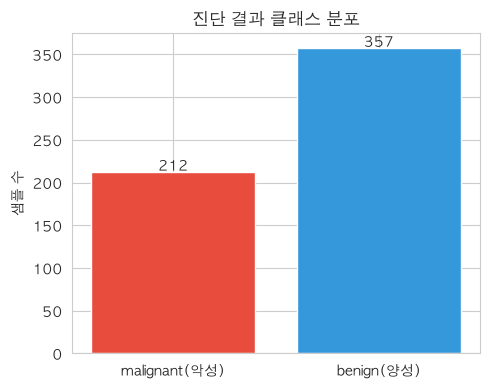

target
0    212
1    357
Name: count, dtype: int64
양성 비율: 62.7%


In [5]:
target_counts = df["target"].value_counts().sort_index()
labels = ["malignant(악성)", "benign(양성)"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, target_counts.values, color=["#e74c3c", "#3498db"])
ax.set_title("진단 결과 클래스 분포")
ax.set_ylabel("샘플 수")
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2, str(count),
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(target_counts)
print(f"양성 비율: {target_counts[1] / len(df):.1%}")


### 2-2. 주요 특징 간 상관관계 (Correlation Heatmap)

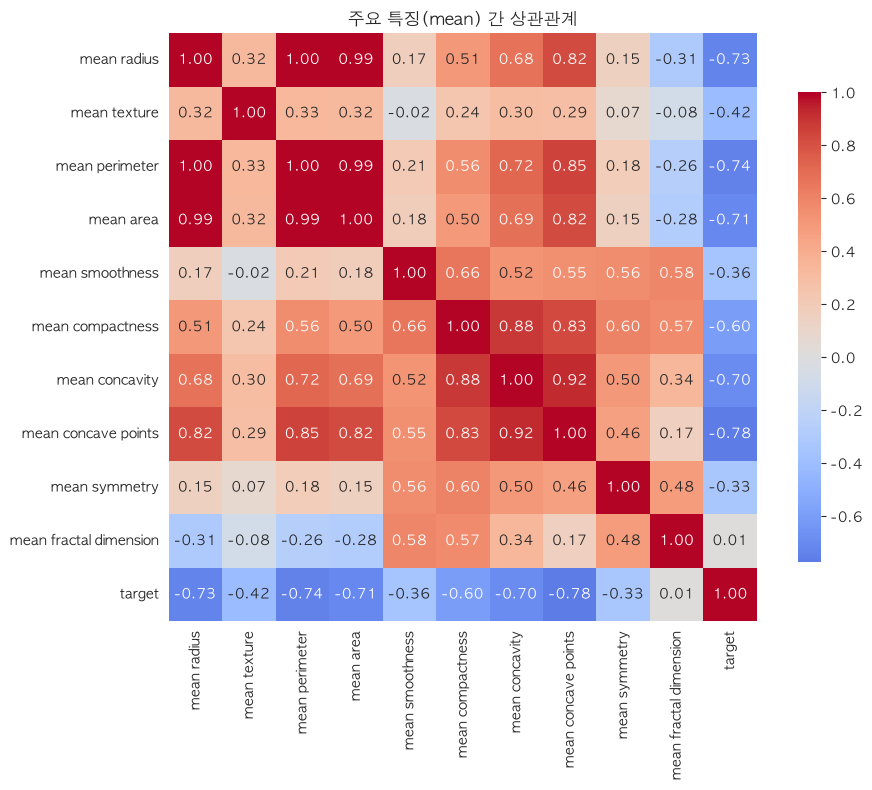

In [6]:
# mean 관련 주요 특징 10개만 선택하여 상관관계 시각화
mean_cols = [c for c in df.columns if c.startswith("mean")]
corr = df[mean_cols + ["target"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("주요 특징(mean) 간 상관관계")
plt.tight_layout()
plt.show()


### 2-3. 악성/양성 그룹별 주요 특징 분포 비교

/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_7111/2530891935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat, ax=ax, palette=["#e74c3c", "#3498db"])
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_7111/2530891935.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["malignant", "benign"])
/var/folders/cn/n1wp5rkx27j7415_2rb44sk00000gn/T/ipykernel_7111/2530891935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat, ax=ax, palette=["#e74c3c", "#3498db"])
/var/folders/cn/n

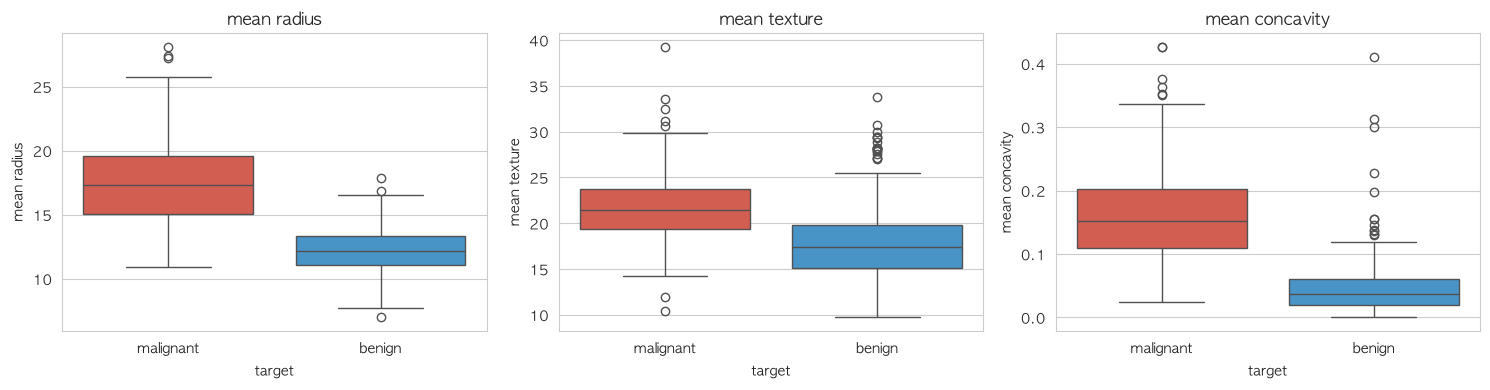

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
key_features = ["mean radius", "mean texture", "mean concavity"]

for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df, x="target", y=feat, ax=ax, palette=["#e74c3c", "#3498db"])
    ax.set_xticklabels(["malignant", "benign"])
    ax.set_title(feat)

plt.tight_layout()
plt.show()


## 3. 데이터 전처리

- 특징(X)과 타겟(y) 분리
- 학습/테스트 데이터 분할 (80:20, 계층 샘플링)
- `StandardScaler`를 이용한 표준화 (딥러닝 모델은 스케일에 민감하므로 필수)

In [8]:
X = df[data.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)


Train shape: (455, 30)
Test shape : (114, 30)


## 4. 머신러닝 모델 (Scikit-learn)

세 가지 대표적인 분류 알고리즘을 학습하고 5-Fold 교차검증 및 테스트셋 성능을 비교합니다.

- **Logistic Regression**: 선형 결정경계 기반의 기본 분류기
- **Random Forest**: 다수의 결정트리를 앙상블한 모델
- **SVM (RBF kernel)**: 비선형 결정경계를 찾는 서포트 벡터 머신

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model": model,
        "cv_accuracy_mean": cv_scores.mean(),
        "cv_accuracy_std": cv_scores.std(),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    print(f"[{name}] CV Acc: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | "
          f"Test Acc: {results[name]['test_accuracy']:.4f} | ROC-AUC: {results[name]['roc_auc']:.4f}")


[Logistic Regression] CV Acc: 0.9780 (+/- 0.0098) | Test Acc: 0.9825 | ROC-AUC: 0.9954
[Random Forest] CV Acc: 0.9626 (+/- 0.0179) | Test Acc: 0.9561 | ROC-AUC: 0.9932
[SVM (RBF)] CV Acc: 0.9670 (+/- 0.0155) | Test Acc: 0.9825 | ROC-AUC: 0.9950


/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/parkchanryong/Desktop/SK네트웍스/SKN_35/data-collection-workspace/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warning

### 4-1. Confusion Matrix 비교

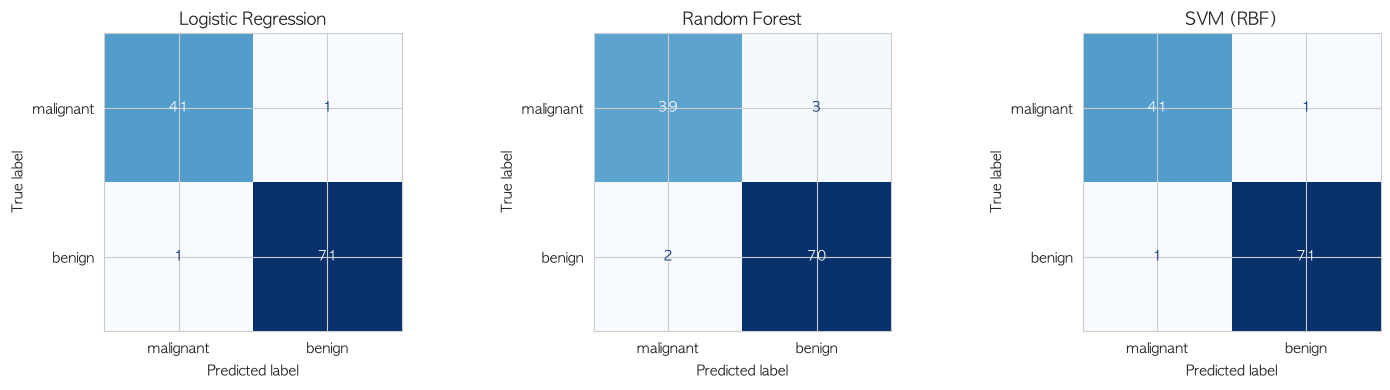

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


### 4-2. ROC Curve 비교

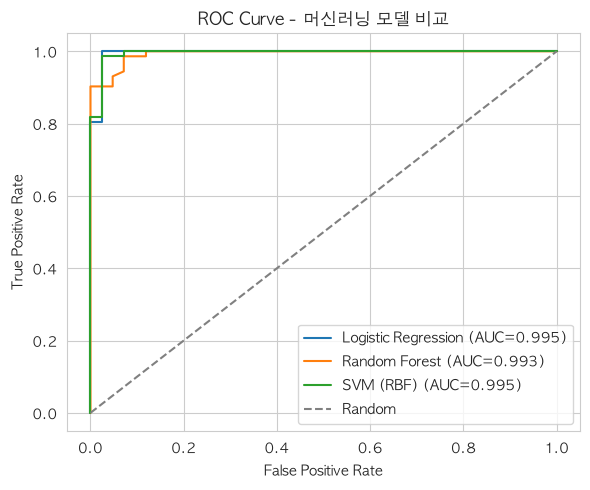

In [11]:
plt.figure(figsize=(6, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 머신러닝 모델 비교")
plt.legend()
plt.tight_layout()
plt.show()


## 5. 딥러닝 - 심층 인공신경망(DNN) 구축

Keras의 `Sequential` API를 사용하여 다층 구조의 심층 신경망을 구축합니다.

**모델 구조**
- Input Layer: 30개 특징
- Hidden Layer 1: Dense(64) + BatchNormalization + ReLU + Dropout(0.3)
- Hidden Layer 2: Dense(32) + BatchNormalization + ReLU + Dropout(0.3)
- Hidden Layer 3: Dense(16) + ReLU
- Output Layer: Dense(1) + Sigmoid (이진 분류)

In [12]:
def build_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(16, activation="relu"),

        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

dnn_model = build_dnn(X_train_scaled.shape[1])
dnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

### 5-1. 모델 학습

EarlyStopping 콜백을 사용해 검증 손실이 개선되지 않으면 학습을 조기 종료하여 과적합을 방지합니다.

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

history = dnn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

print(f"실제 학습된 epoch 수: {len(history.history['loss'])}")


실제 학습된 epoch 수: 77


### 5-2. 학습 곡선 시각화 (Loss / Accuracy)

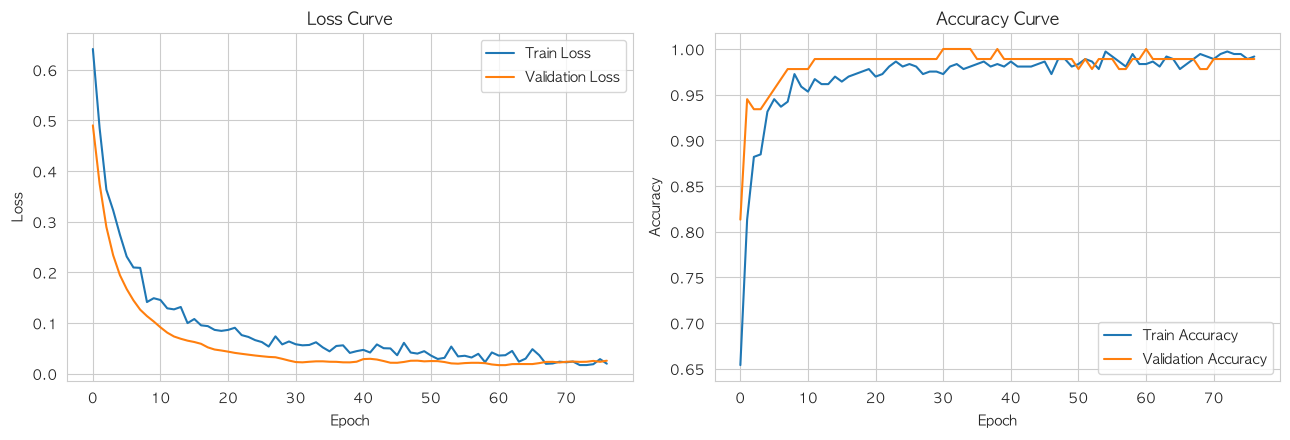

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


### 5-3. 테스트셋 평가

In [15]:
y_proba_dnn = dnn_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_dnn = (y_proba_dnn >= 0.5).astype(int)

dnn_result = {
    "test_accuracy": accuracy_score(y_test, y_pred_dnn),
    "precision": precision_score(y_test, y_pred_dnn),
    "recall": recall_score(y_test, y_pred_dnn),
    "f1": f1_score(y_test, y_pred_dnn),
    "roc_auc": roc_auc_score(y_test, y_proba_dnn),
}
results["Deep Neural Network"] = dnn_result

for k, v in dnn_result.items():
    print(f"{k}: {v:.4f}")


test_accuracy: 0.9561
precision: 0.9718
recall: 0.9583
f1: 0.9650
roc_auc: 0.9924


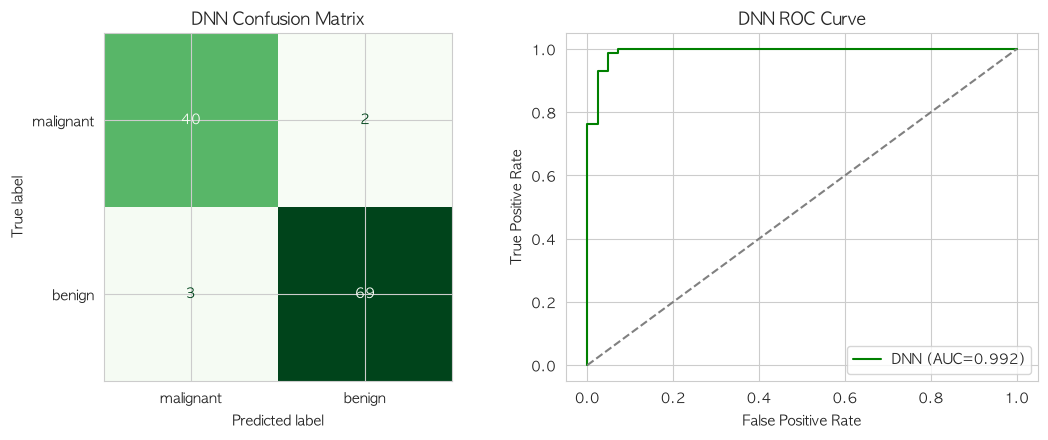

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred_dnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
disp.plot(ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title("DNN Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba_dnn)
axes[1].plot(fpr, tpr, label=f"DNN (AUC={dnn_result['roc_auc']:.3f})", color="green")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("DNN ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. 전체 모델 성능 종합 비교

머신러닝 3개 모델과 딥러닝 모델(DNN)의 테스트셋 성능을 하나의 표와 그래프로 비교합니다.

In [17]:
summary_df = pd.DataFrame({
    name: {
        "Accuracy": res["test_accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-score": res["f1"],
        "ROC-AUC": res["roc_auc"],
    }
    for name, res in results.items()
}).T.round(4)

summary_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9932
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
Deep Neural Network,0.9561,0.9718,0.9583,0.9650,0.9924


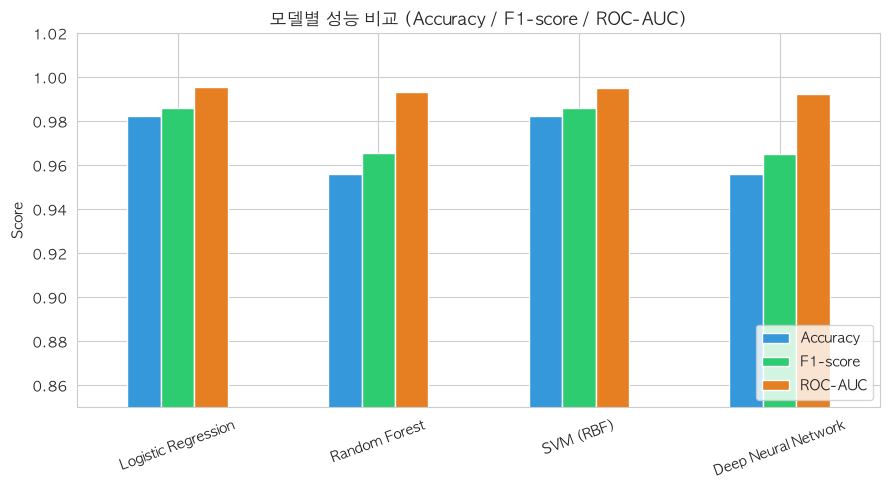

In [18]:
summary_df[["Accuracy", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 5), rot=20,
    color=["#3498db", "#2ecc71", "#e67e22"]
)
plt.title("모델별 성능 비교 (Accuracy / F1-score / ROC-AUC)")
plt.ylabel("Score")
plt.ylim(0.85, 1.02)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. 결론

- 4개 모델(Logistic Regression, Random Forest, SVM, DNN) 모두 이 데이터셋에서 **95% 이상의 높은 정확도**를 보였습니다.
- 데이터의 특징 수가 적당하고(30개) 샘플 수가 크지 않은(569개) 정형 데이터에서는, **전통 머신러닝 모델(특히 로지스틱 회귀, SVM)도 딥러닝 모델과 대등하거나 더 나은 성능**을 보이는 경우가 많습니다.
- 딥러닝(DNN)은 대규모 데이터 및 복잡한 비선형 패턴에서 강점을 보이는 반면, 이런 소규모 정형 데이터에서는 과적합 방지(Dropout, BatchNorm, EarlyStopping)를 세심하게 적용해야 안정적인 성능을 낼 수 있음을 확인했습니다.
- 실무에서는 데이터 규모와 특성에 따라 **머신러닝과 딥러닝을 적절히 선택하거나 앙상블**하는 것이 중요합니다.

### 추가로 시도해볼 수 있는 것들
- `GridSearchCV` / `RandomizedSearchCV`를 이용한 하이퍼파라미터 튜닝
- `RandomForest`의 특징 중요도(feature importance) 분석
- DNN 레이어 수, 뉴런 수, learning rate 등을 바꿔가며 성능 변화 비교
- 다른 데이터셋(Wine, Digits 등)에 동일한 파이프라인 적용해보기
